cuda
[[ 4.805730e+01  1.108620e+01  2.957100e+00 ... -2.299200e+00
   2.693000e+01  1.652240e+02]
 [ 2.348580e+01  0.000000e+00  2.239300e+00 ...  1.000000e-04
   1.934100e+01  2.353420e+02]
 [ 4.054290e+01  1.940730e+01  3.338200e+00 ... -7.124300e+00
   1.006430e+01  1.956030e+02]
 ...
 [ 1.999260e+01  1.208660e+01  2.435400e+00 ...  9.437400e+00
   1.277190e+01  1.938930e+02]
 [ 3.143360e+01  2.326510e+01  2.934000e+00 ...  1.928930e+01
   7.995900e+01  2.323630e+01]
 [ 5.087450e+01  1.057630e+01  2.524400e+00 ... -1.315140e+01
   5.967810e+01  1.584316e+02]]
[1 0 0 ... 0 0 1]


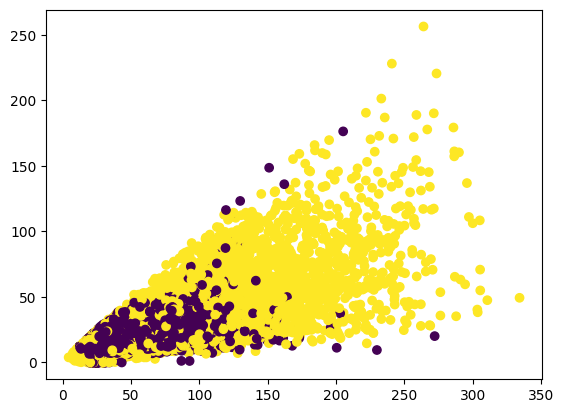

In [1]:
from kan import *
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import shuffle
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

heart = fetch_ucirepo(id=159)
X = heart.data.features._values
y = heart.data.targets._values[:,0]

class_mapping = {'g': 0, 'h': 1}
y = np.vectorize(class_mapping.get)(y)

X, y = shuffle(X, y, random_state=42)

skf = StratifiedKFold(n_splits=5)


print(X)
print(y)
dtype = torch.get_default_dtype()
X_plot = torch.from_numpy(X).type(dtype).to(device)
y_plot = torch.from_numpy(y).type(dtype).to(device)
plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,1].cpu().detach().numpy(), c=y_plot[:].cpu().detach().numpy())
plt.show()

Params: 1080


| train_loss: 5.39e-01 | test_loss: 5.58e-01 | reg: 0.00e+00 | : 100%|█| 500/500 [00:15<00:00, 32.00
| train_loss: 5.37e-01 | test_loss: 5.72e-01 | reg: 0.00e+00 | : 100%|█| 500/500 [00:13<00:00, 35.84
| train_loss: 5.42e-01 | test_loss: 5.56e-01 | reg: 0.00e+00 | : 100%|█| 500/500 [00:13<00:00, 37.16
| train_loss: 5.44e-01 | test_loss: 5.70e-01 | reg: 0.00e+00 | : 100%|█| 500/500 [00:13<00:00, 36.23
| train_loss: 5.40e-01 | test_loss: 5.60e-01 | reg: 0.00e+00 | : 100%|█| 500/500 [00:14<00:00, 35.25


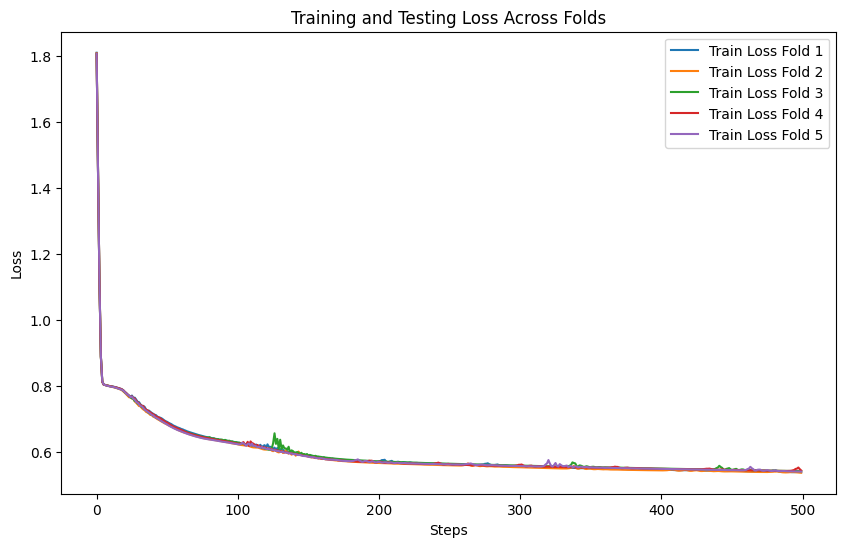

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
import time

dataset = {}
results = []

train_cms = []
test_cms = []

model = None

def train_acc_f():
    predictions = torch.argmax(model(dataset['train_input']), dim=1)
    return torch.mean((predictions == dataset['train_label']).type(dtype))
def test_acc_f():
    predictions = torch.argmax(model(dataset['test_input']), dim=1)
    return torch.mean((predictions == dataset['test_label']).type(dtype))

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()  # Extract confusion matrix components
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='binary'),
        "recall": recall_score(y_true, y_pred, average='binary'),
        "f1_score": f1_score(y_true, y_pred, average='binary'),
        "fpr": fpr,
        "fnr": fnr
    }
    return metrics
#depth~3 too deep for this dataset
layer=6
KAN_width=[X.shape[1], layer, layer, 2]
KAN_g=5
KAN_k=3
n_params = 0
for i in range(len(KAN_width)-1):
    n_params += KAN_width[i]*KAN_width[i+1]*(KAN_g+KAN_k+2)
print("Params:", n_params)

kan_train_metrics = []
kan_test_metrics = []
time_list=[]

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    dataset['train_input'] = torch.from_numpy(X[train_index]).type(torch.FloatTensor).to(device)
    dataset['test_input'] = torch.from_numpy(X[test_index]).type(torch.FloatTensor).to(device)
    dataset['train_label'] = torch.from_numpy(y[train_index]).type(torch.LongTensor).to(device)
    dataset['test_label'] = torch.from_numpy(y[test_index]).type(torch.LongTensor).to(device)

    model = KAN(width=KAN_width, grid=KAN_g, k=KAN_k, device=device, save_act=False, auto_save=False, seed=1)
    
    start_time = time.time()
    results.append(model.fit(dataset, opt="Adam", steps=500, loss_fn=torch.nn.CrossEntropyLoss(), lr=0.01))
    end_time = time.time()
    time_list.append(end_time - start_time)

    train_predictions = torch.argmax(model(dataset['train_input']), dim=1).cpu().numpy()
    test_predictions = torch.argmax(model(dataset['test_input']), dim=1).cpu().numpy()

    train_labels = dataset['train_label'].cpu().numpy()
    test_labels = dataset['test_label'].cpu().numpy()

    #metrics
    kan_train_metrics.append(compute_metrics(train_labels, train_predictions))
    kan_test_metrics.append(compute_metrics(test_labels, test_predictions))
    train_cms.append(confusion_matrix(train_labels, train_predictions))
    test_cms.append(confusion_matrix(test_labels, test_predictions))
    


plt.figure(figsize=(10, 6))

for i, result in enumerate(results):
    plt.plot(result['train_loss'], label=f'Train Loss Fold {i+1}')


plt.legend()
plt.ylabel('Loss')
plt.xlabel('Steps')
plt.title('Training and Testing Loss Across Folds')
plt.yscale('linear')
plt.show()

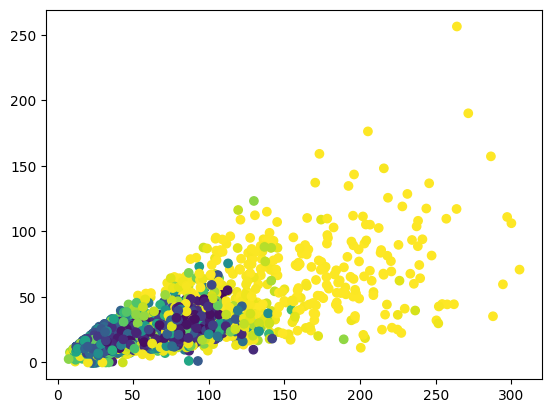

In [3]:
X_plot = dataset['test_input']
y_plot = model.forward(dataset['test_input'])[:, 1]
y_normalized = 1/(1 + np.exp(-y_plot.cpu().detach().numpy()))

plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,1].cpu().detach().numpy(), c=y_normalized)
plt.show()

Train Metrics:
accuracy: 0.8810 ± 0.0006
precision: 0.8789 ± 0.0041
recall: 0.7673 ± 0.0037
f1_score: 0.8193 ± 0.0009
fpr: 0.0574 ± 0.0024
fnr: 0.2327 ± 0.0037

Test Metrics:
accuracy: 0.8756 ± 0.0017
precision: 0.8696 ± 0.0056
recall: 0.7602 ± 0.0089
f1_score: 0.8111 ± 0.0036
fpr: 0.0619 ± 0.0036
fnr: 0.2398 ± 0.0089

Time Metrics: 14.2148 ± 0.7635


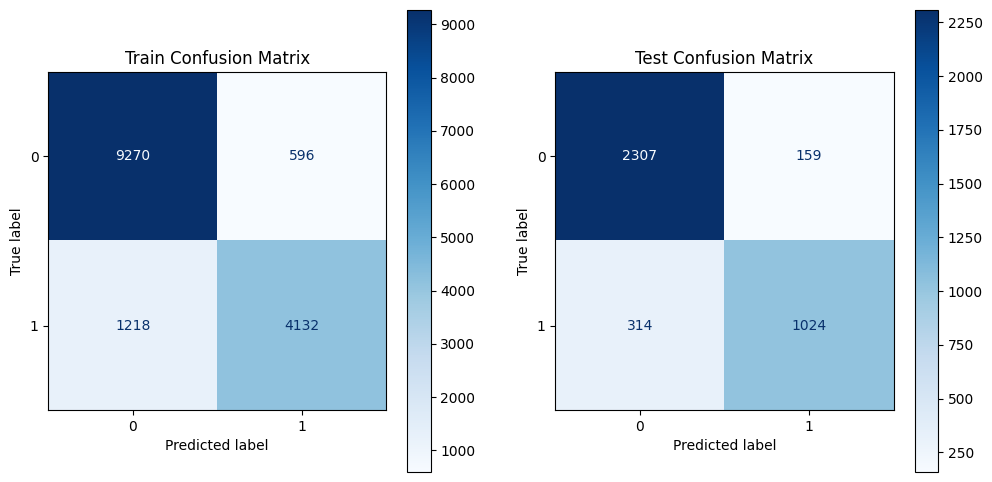

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

def aggregate_metrics(metrics_list):
    aggregated = {}
    for key in metrics_list[0].keys():
        values = [metrics[key] for metrics in metrics_list]
        aggregated[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
    return aggregated
def aggregate_time(time_list):
    aggregated = {
        "mean": np.mean(time_list),
        "std": np.std(time_list)
    }
    return aggregated

train_metrics_summary = aggregate_metrics(kan_train_metrics)
test_metrics_summary = aggregate_metrics(kan_test_metrics)
time_metrics_summary= aggregate_time(time_list)

print("Train Metrics:")
for key, value in train_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print("\nTest Metrics:")
for key, value in test_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print(f"\nTime Metrics: {time_metrics_summary['mean']:.4f} ± {time_metrics_summary['std']:.4f}")


with open(f"KAN_{n_params}.txt", "w") as file:
    mean=test_metrics_summary["accuracy"]["mean"]
    std=test_metrics_summary["accuracy"]["std"]
    file.write(f"{mean:.4f} {std:.4f}\n")


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ConfusionMatrixDisplay(train_cms[0]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay(test_cms[0]).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Test Confusion Matrix')

plt.show()

MLP

Params: 1084
Train Metrics: {'accuracy': {'mean': np.float64(0.871437960042061), 'std': np.float64(0.009391280603588107)}, 'precision': {'mean': np.float64(0.8763422264482656), 'std': np.float64(0.010804680235371195)}, 'recall': {'mean': np.float64(0.7385599966466221), 'std': np.float64(0.02346571442515994)}, 'f1_score': {'mean': np.float64(0.8014213347277312), 'std': np.float64(0.016398308374914967)}, 'fpr': {'mean': np.float64(0.05649934361190073), 'std': np.float64(0.004916668992844344)}, 'fnr': {'mean': np.float64(0.2614400033533779), 'std': np.float64(0.02346571442515991)}}
Test Metrics: {'accuracy': {'mean': np.float64(0.8530494216614091), 'std': np.float64(0.007269983603551463)}, 'precision': {'mean': np.float64(0.8444859589533461), 'std': np.float64(0.007326513999348338)}, 'recall': {'mean': np.float64(0.7136756207425096), 'std': np.float64(0.026834949181134497)}, 'f1_score': {'mean': np.float64(0.7732657039311195), 'std': np.float64(0.01486114974027867)}, 'fpr': {'mean': np.fl

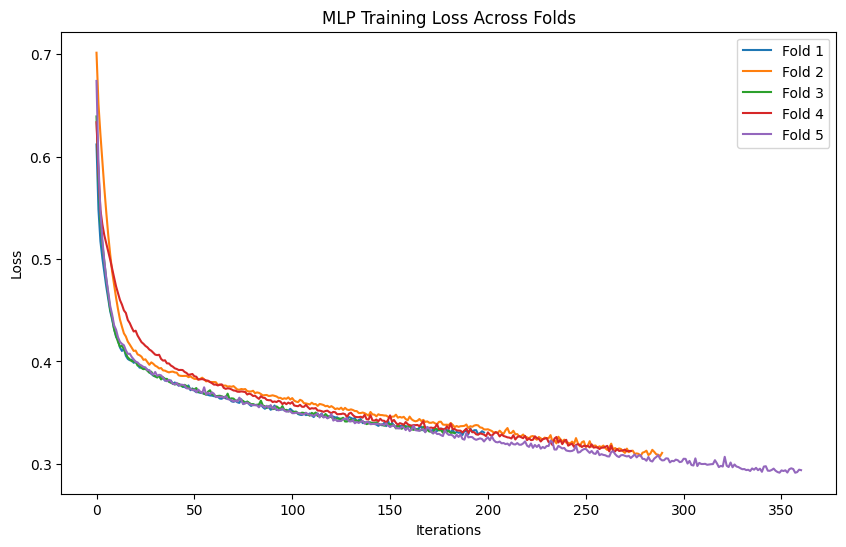

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import time

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()  # Extract confusion matrix components
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='binary'),
        "recall": recall_score(y_true, y_pred, average='binary'),
        "f1_score": f1_score(y_true, y_pred, average='binary'),
        "fpr": fpr,
        "fnr": fnr
    }
    return metrics

#depth>2 too deep for this dataset
leyer=63
hidden_layer_size = (leyer, layer)
params=(X.shape[1], *hidden_layer_size, 1)
n_params = 0
for i in range(len(params)-1):
    n_params += params[i]*params[i+1]+params[i+1]
print("Params:", n_params)

results = []
train_metrics = []
test_metrics = []
time_list=[]

y = y.cpu().detach().numpy() if isinstance(y, torch.Tensor) else y
for train_index, test_index in skf.split(X, y):
    train_input = X[train_index]
    train_label = y[train_index]
    test_input = X[test_index]
    test_label = y[test_index]
    
    mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_size, activation='logistic', solver='adam', max_iter=500)
    
    start_time = time.time()
    mlp.fit(train_input, train_label)
    end_time = time.time()
    time_list.append(end_time - start_time)
    
    train_predictions = mlp.predict(train_input)
    test_predictions = mlp.predict(test_input)

    results.append(mlp.loss_curve_)
    train_metrics.append(compute_metrics(train_label, train_predictions))
    test_metrics.append(compute_metrics(test_label, test_predictions))

train_metrics_summary = aggregate_metrics(train_metrics)
test_metrics_summary = aggregate_metrics(test_metrics)

print("Train Metrics:", train_metrics_summary)
print("Test Metrics:", test_metrics_summary)

plt.figure(figsize=(10, 6))
for i, loss_curve in enumerate(results):
    plt.plot(loss_curve, label=f'Fold {i+1}')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Training Loss Across Folds')
plt.legend()
plt.show()

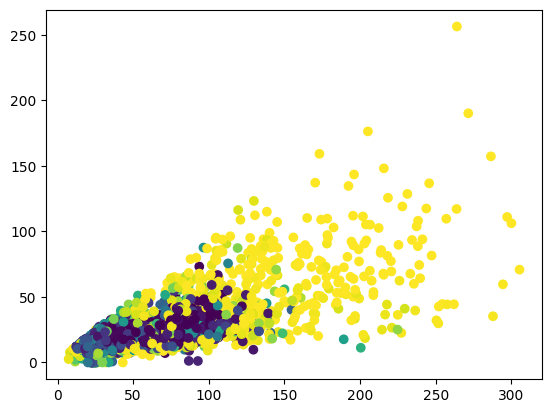

In [6]:
X_plot = dataset['test_input']
y_plot = mlp.predict_proba(dataset['test_input'].cpu().numpy())[:, 1]
plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,1].cpu().detach().numpy(), c=y_plot)
plt.show()

Train Metrics:
accuracy: 0.8810 ± 0.0006
precision: 0.8789 ± 0.0041
recall: 0.7673 ± 0.0037
f1_score: 0.8193 ± 0.0009
fpr: 0.0574 ± 0.0024
fnr: 0.2327 ± 0.0037

Test Metrics:
accuracy: 0.8756 ± 0.0017
precision: 0.8696 ± 0.0056
recall: 0.7602 ± 0.0089
f1_score: 0.8111 ± 0.0036
fpr: 0.0619 ± 0.0036
fnr: 0.2398 ± 0.0089

Time Metrics: 15.8545 ± 4.0030


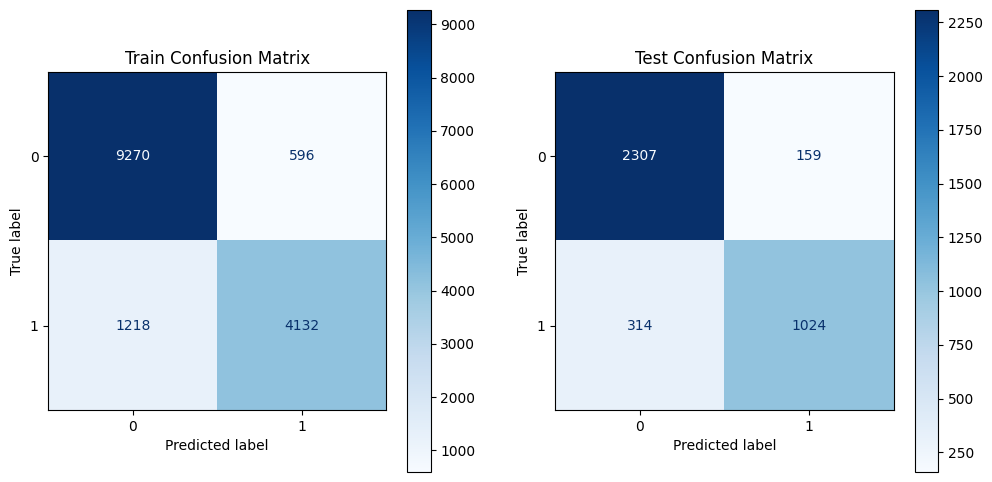

In [7]:
def aggregate_metrics(metrics_list):
    aggregated = {}
    for key in metrics_list[0].keys():
        values = [metrics[key] for metrics in metrics_list]
        aggregated[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
    return aggregated
def aggregate_time(time_list):
    aggregated = {
        "mean": np.mean(time_list),
        "std": np.std(time_list)
    }
    return aggregated

train_metrics_summary = aggregate_metrics(kan_train_metrics)
test_metrics_summary = aggregate_metrics(kan_test_metrics)
time_metrics_summary= aggregate_time(time_list)

print("Train Metrics:")
for key, value in train_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print("\nTest Metrics:")
for key, value in test_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print(f"\nTime Metrics: {time_metrics_summary['mean']:.4f} ± {time_metrics_summary['std']:.4f}")


with open(f"MLP_{n_params}.txt", "w") as file:
    mean=test_metrics_summary["accuracy"]["mean"]
    std=test_metrics_summary["accuracy"]["std"]
    file.write(f"{mean:.4f} {std:.4f}\n")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ConfusionMatrixDisplay(train_cms[0]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay(test_cms[0]).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Test Confusion Matrix')

plt.show()